<a href="https://colab.research.google.com/github/Farida-webb/Feride/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.zeros((20,20))

# əsas yol (ana xətt)
grid[5:15, 10] = 0

# alternativ yollar
grid[10, 3:17] = 0
grid[3:17, 5] = 0

# maneələr
grid[8,10] = 1   # əsas yolun bir hissəsi bağlanır

In [2]:
start = (1,1)   # giriş
goal  = (4,4) # sağ sahil

In [3]:
path1 = astar(grid, start, goal)

NameError: name 'astar' is not defined

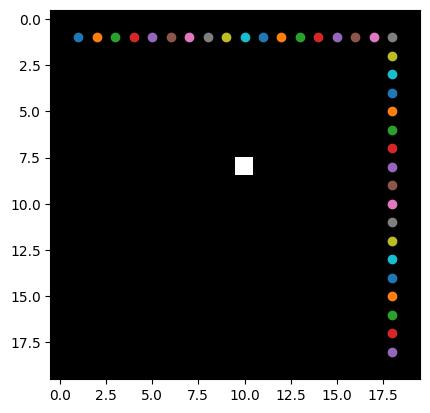

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

# A* FUNKSİYA
def astar(grid, start, goal):
    rows, cols = len(grid), len(grid[0])
    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}
    g_score = {start: 0}

    directions = [(0,1),(1,0),(0,-1),(-1,0)]

    while open_list:
        _, current = heapq.heappop(open_list)

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            return path[::-1]

        for d in directions:
            neighbor = (current[0]+d[0], current[1]+d[1])

            if 0 <= neighbor[0] < rows and 0 <= neighbor[1] < cols:
                if grid[neighbor[0]][neighbor[1]] == 1:
                    continue

                temp_g = g_score[current] + 1

                if neighbor not in g_score or temp_g < g_score[neighbor]:
                    g_score[neighbor] = temp_g
                    f = temp_g + abs(neighbor[0]-goal[0]) + abs(neighbor[1]-goal[1])
                    heapq.heappush(open_list, (f, neighbor))
                    came_from[neighbor] = current
    return None


# XƏRİTƏ
grid = np.zeros((20,20))
grid[8,10] = 1

# START & GOAL
start = (1,1)
goal = (18,18)

# YOL TAP
path = astar(grid, start, goal)

# GÖSTƏR
plt.imshow(grid, cmap='gray')

for (x,y) in path:
    plt.scatter(y, x)

plt.show()

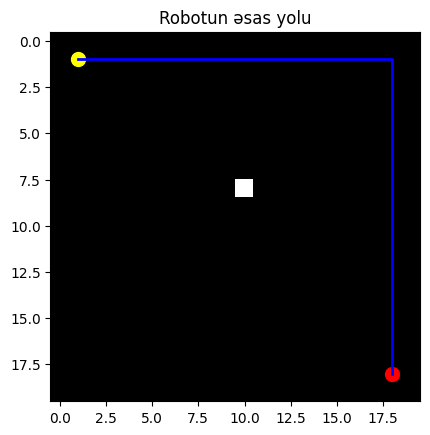

In [5]:
plt.imshow(grid, cmap='gray')

# path koordinatlarını ayır
x_coords = [p[0] for p in path]
y_coords = [p[1] for p in path]

# xətt kimi çək
plt.plot(y_coords, x_coords, 'b-', linewidth=2)

# start və goal
plt.scatter(start[1], start[0], c='yellow', s=100)
plt.scatter(goal[1], goal[0], c='red', s=100)

plt.title("Robotun əsas yolu")
plt.show()

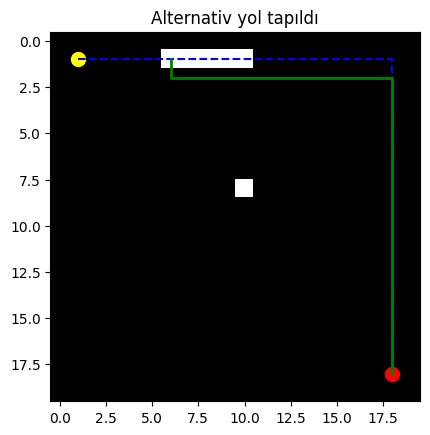

In [6]:
# yolu bağla
for (x,y) in path[5:10]:
    grid[x][y] = 1

# yeni yol
new_path = astar(grid, path[5], goal)

# çək
plt.imshow(grid, cmap='gray')

# köhnə yol
plt.plot(y_coords, x_coords, 'b--')

# yeni yol
x2 = [p[0] for p in new_path]
y2 = [p[1] for p in new_path]

plt.plot(y2, x2, 'g-', linewidth=2)

plt.scatter(start[1], start[0], c='yellow', s=100)
plt.scatter(goal[1], goal[0], c='red', s=100)

plt.title("Alternativ yol tapıldı")
plt.show()

In [7]:
def find_multiple_paths(grid, start, goal, k=5):
    import copy

    paths = []
    temp_grid = copy.deepcopy(grid)

    for i in range(k):
        p = astar(temp_grid, start, goal)
        if p is None:
            break

        paths.append(p)

        # həmin yolu zəiflət (tam bloklama yox, hissəvi)
        for (x,y) in p[1:-1:2]:  # hər 2-ci nöqtəni blokla
            temp_grid[x][y] = 1

    return paths

In [8]:
paths = find_multiple_paths(grid, start, goal, k=4)

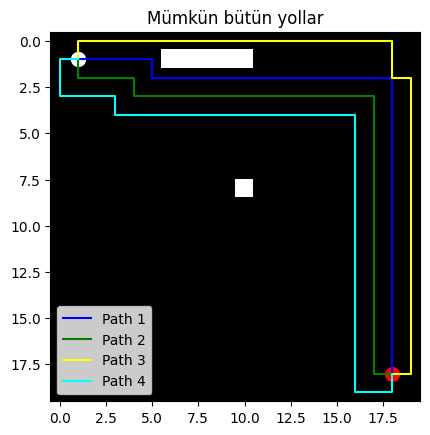

In [9]:
plt.imshow(grid, cmap='gray')

colors = ['blue','green','yellow','cyan']

for i, p in enumerate(paths):
    x = [pt[0] for pt in p]
    y = [pt[1] for pt in p]
    plt.plot(y, x, color=colors[i], label=f'Path {i+1}')

plt.scatter(start[1], start[0], c='white', s=100)
plt.scatter(goal[1], goal[0], c='red', s=100)

plt.legend()
plt.title("Mümkün bütün yollar")
plt.show()

In [10]:
current_path_index = 0
current_position = start

final_path = []

while current_position != goal and current_path_index < len(paths):

    current_path = paths[current_path_index]

    for step in current_path:
        final_path.append(step)
        current_position = step

        # SÜNİ BAĞLANMA (məsələn)
        if step == current_path[len(current_path)//2]:
            print("Yol bağlandı! Alternativ seçilir...")

            # yeni yol tap
            new_path = astar(grid, current_position, goal)

            if new_path:
                paths.append(new_path)
                current_path_index += 1
                break
    else:
        break

Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...
Yol bağlandı! Alternativ seçilir...


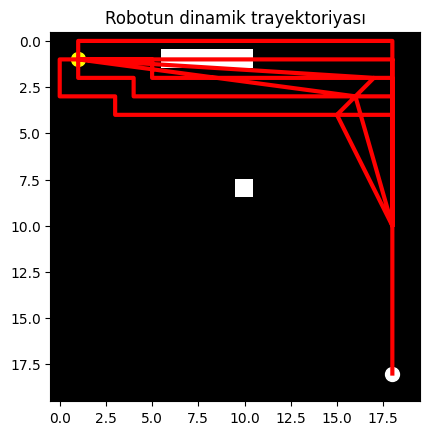

In [11]:
plt.imshow(grid, cmap='gray')

x = [p[0] for p in final_path]
y = [p[1] for p in final_path]

plt.plot(y, x, 'r-', linewidth=3)

plt.scatter(start[1], start[0], c='yellow', s=100)
plt.scatter(goal[1], goal[0], c='white', s=100)

plt.title("Robotun dinamik trayektoriyası")
plt.show()

In [12]:
import numpy as np
import random

grid = np.zeros((10,10))

# maneələr (şəhər kimi)
grid[4, 2:8] = 1
grid[6, 1:5] = 1

start = (0,0)
goal  = (9,9)

actions = [(0,1),(1,0),(0,-1),(-1,0)]  # sağ, aşağı, sol, yuxarı

Q = np.zeros((10,10,4))  # Q-table

In [13]:
def reward(state, next_state):
    x,y = next_state

    if x<0 or x>=10 or y<0 or y>=10:
        return -100  # sərhəddən çıxdı

    if grid[x][y] == 1:
        return -100  # maneə

    if next_state == goal:
        return 100  # məqsədə çatdı

    return -1  # hər addım kiçik cəza (qısa yol üçün)

In [14]:
alpha = 0.1   # learning rate
gamma = 0.9   # discount
epsilon = 0.2 # exploration

episodes = 500

for ep in range(episodes):
    state = start

    while state != goal:

        x,y = state

        # action seçimi (explore vs exploit)
        if random.random() < epsilon:
            a = random.randint(0,3)
        else:
            a = np.argmax(Q[x,y])

        dx,dy = actions[a]
        next_state = (x+dx, y+dy)

        r = reward(state, next_state)

        nx,ny = next_state if 0<=next_state[0]<10 and 0<=next_state[1]<10 else state

        # Q update
        Q[x,y,a] = Q[x,y,a] + alpha * (r + gamma * np.max(Q[nx,ny]) - Q[x,y,a])

        if r == -100:
            break

        state = next_state

In [15]:
path = []
state = start

while state != goal:
    path.append(state)
    x,y = state
    a = np.argmax(Q[x,y])
    dx,dy = actions[a]
    state = (x+dx, y+dy)

path.append(goal)

KeyboardInterrupt: 

In [16]:
path = []
state = start

max_steps = 100  # LIMIT
steps = 0

while state != goal and steps < max_steps:
    path.append(state)
    x,y = state

    a = np.argmax(Q[x,y])
    dx,dy = actions[a]

    next_state = (x+dx, y+dy)

    # sərhəd yoxla
    if not (0 <= next_state[0] < 10 and 0 <= next_state[1] < 10):
        break

    state = next_state
    steps += 1

path.append(state)

In [17]:
visited = set()

while state != goal and steps < max_steps:

    if state in visited:
        print("Loop aşkarlandı!")
        break

    visited.add(state)

    path.append(state)

    x,y = state
    a = np.argmax(Q[x,y])
    dx,dy = actions[a]

    state = (x+dx, y+dy)
    steps += 1

In [18]:
if state != goal:
    print("RL yolu tapa bilmədi → A* istifadə olunur")
    path = astar(grid, start, goal)

RL yolu tapa bilmədi → A* istifadə olunur


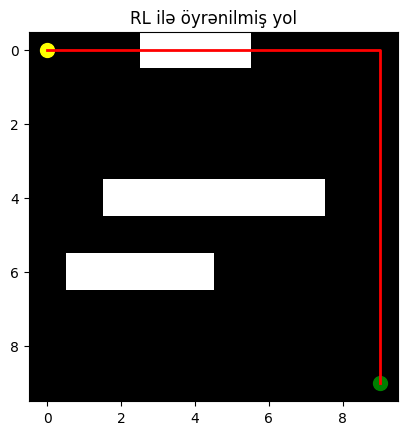

In [21]:
import matplotlib.pyplot as plt

plt.imshow(grid, cmap='gray')

x = [p[0] for p in path]
y = [p[1] for p in path]

plt.plot(y, x, 'r-', linewidth=2)

plt.scatter(start[1], start[0], c='yellow', s=100)
plt.scatter(goal[1], goal[0], c='green', s=100)

plt.title("RL ilə öyrənilmiş yol")
plt.show()

In [20]:
# yolun bir hissəsini bağla
for (x,y) in path[3:6]:
    grid[x][y] = 1

# yenidən öyrən
# (yuxarıdakı training blokunu yenidən run et)

# yeni yol çıxar